# ✨ Project Overview: Unsupervised Clustering for Stellar Astronomy

This project applies **Unsupervised Learning** to astronomical data (star coordinates) with the objective of creating a robust model to identify **stellar clusters** in star-forming regions. The exercise emphasizes model selection, optimal hyperparameter estimation, and quantitative cluster validation.

---

## 🔭 Ex 1.1: K-Means Clustering and Hyperparameter Tuning

| ML/Data Science Principle | Concept | Goal |
| :--- | :--- | :--- |
| **Initial Data Visualization** | **Visual Guessing (EDA)** | Plotting the (X, Y) coordinates to visually guess the optimal number of clusters ($k$). This provides a necessary starting point before formal tuning. |
| **K-Means Clustering** | **Centroid-Based Clustering** | Using the **K-Means algorithm** to partition the data into $k$ clusters, where the goal is to minimize the variance within each cluster. |
| **Hyperparameter Tuning** | **Elbow Method (Inertia)** | Systematically testing various values of the $k$ hyperparameter (number of clusters) and plotting the **Inertia** (Within-Cluster Sum of Squares) to find the "elbow point." This point is the standard heuristic for identifying the optimal number of natural clusters ($k$). |
| **Centroid Interpretation** | **Cluster Representation** | Once $k$ is optimized, the final **centroids** are calculated, representing the average, central position of each stellar cluster on the sky. |

---

## 📏 Ex 1.2 - 1.4: Cluster Validation Metrics

This section moves beyond visual assessment to quantitatively validate the quality and compactness of the generated clusters.

| Task | Statistical/ML Principle | Function/Goal |
| :--- | :--- | :--- |
| **Ex. 1.2** | **Davies-Bouldin Index (DBI)** | **Internal Validation Metric:** Writing a custom function (avoiding the built-in library) to calculate the DBI. This metric measures the **average similarity between clusters**. A *lower* DBI score indicates better clustering (clusters are more compact and further apart). |
| **Ex. 1.3** | **Quantitative Assessment** | **Model Selection & Interpretation:** Using the DBI score as the quantitative measure to assess which cluster configuration ($k=3$ vs. $k=5$) is statistically superior. This demonstrates using a formal statistical basis to justify model choice. |
| **Ex. 1.4 [Bonus]** | **Calinski-Harabasz Index (CHI)** | **Internal Validation Metric:** Calculating the CHI (Variance Ratio Criterion). This metric measures the ratio of the **between-cluster dispersion** to the **within-cluster dispersion**. A *higher* CHI score indicates better-defined and more separated clusters. |

---

## 🔄 Ex 2.1 & 2.2: Algorithm Comparison (K-Means vs. DBSCAN)

This final exercise contrasts two fundamentally different clustering approaches for the same dataset.

| Task | ML/Data Science Principle | Concept Demonstrated |
| :--- | :--- | :--- |
| **Ex. 2.1** | **Density-Based Clustering (DBSCAN)** | **Clustering Arbitrary Shapes:** Adopting DBSCAN, which identifies clusters based on the **density** of data points rather than predefined centroids. This is crucial for discovering non-spherical or oddly shaped stellar groups. |
| **Ex. 2.1** | **Hyperparameter Tuning ($\epsilon$, min\_samples)** | Tuning the $\epsilon$ (radius for neighboring points) and `min_samples` (density threshold) parameters. These parameters directly control what the algorithm defines as a dense region and how it separates noise. |
| **Ex. 2.2** | **Comparative Model Selection** | **Algorithm Justification:** Directly comparing the results of **K-Means** (best for spherical, equally sized clusters) and **DBSCAN** (best for arbitrary shapes and identifying noise). The argument in favor of one method (e.g., DBSCAN if clusters are non-spherical) must be grounded in the visual results and the underlying **scientific context** of how stars are physically distributed. |

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# Ex 1

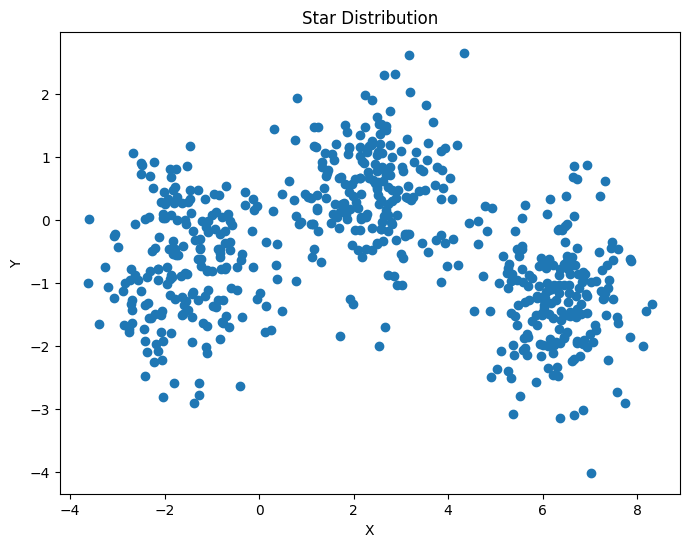

In [70]:
data = pd.read_csv('HW07_data.csv')
#scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(data['RA'], data['Dec'])
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Star Distribution')
plt.show()


import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

data = pd.read_csv("HW07_data.csv")


X = data[['RA']]
y = data[['Dec']]


# Noemalize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y)


kmeans = KMeans(n_clusters=3, random_state=0).fit(X_scaled) 
labels = kmeans.labels_



### Guess:

From the plot it seems likely that we have 3 clusters

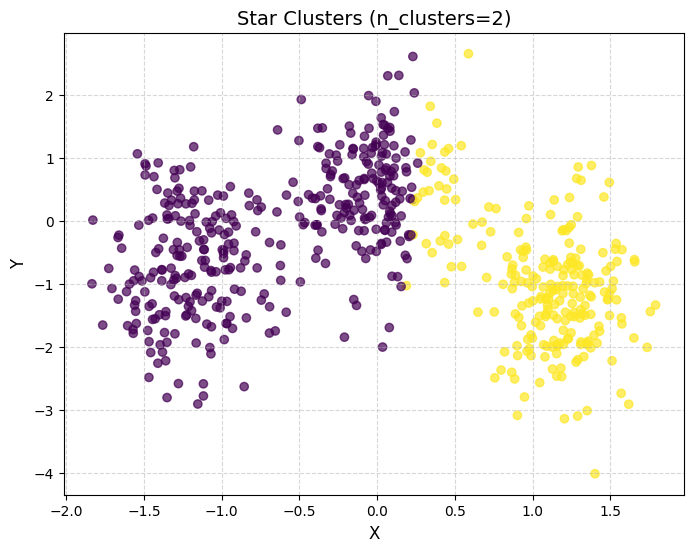

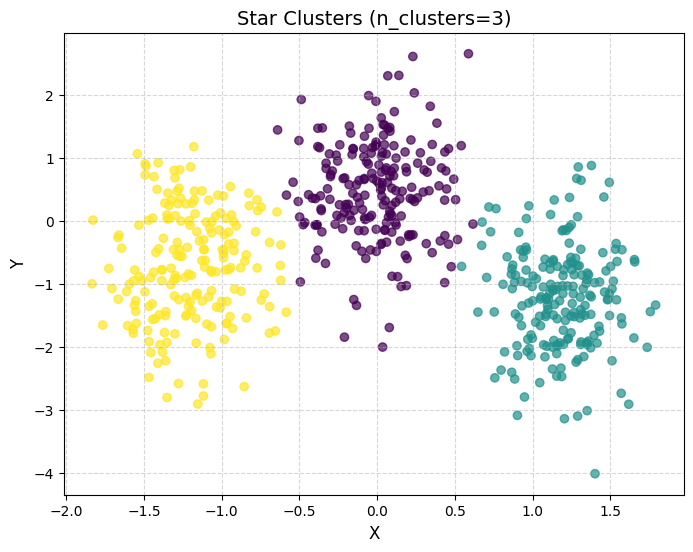

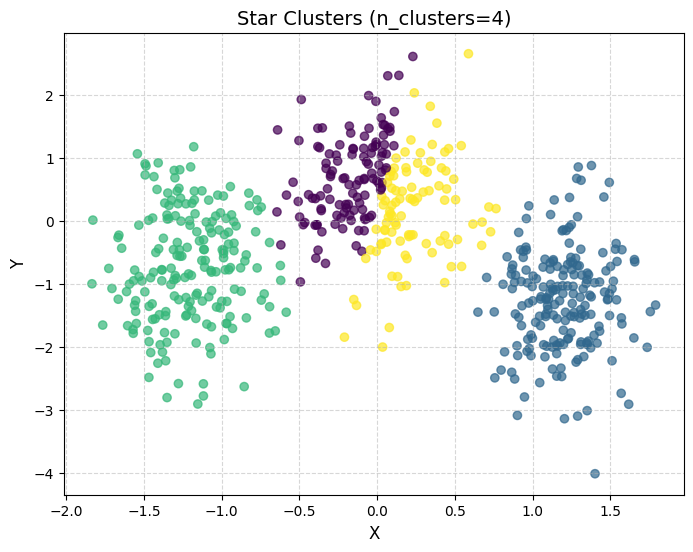

In [71]:
for n_clusters in range(2, 5): 
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(data)
    
    
    plt.figure(figsize=(8, 6))
    plt.scatter(X_scaled, data['Dec'], c=kmeans.labels_, cmap='viridis', alpha=0.7)
    plt.xlabel('X', fontsize=12)
    plt.ylabel('Y', fontsize=12)
    plt.title(f'Star Clusters (n_clusters={n_clusters})', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()


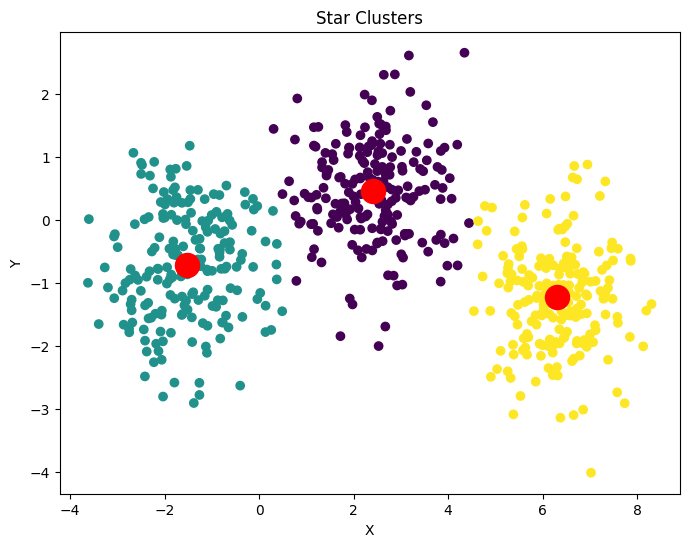

Cluster Centroids:
[[ 2.40220016  0.46933107]
 [-1.53604976 -0.71939755]
 [ 6.3108396  -1.22437637]]


In [72]:
# applying the KMeans using a number of 3 clusters
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=0)
kmeans.fit(data)

# Plotting 
plt.figure(figsize=(8, 6))
plt.scatter(data['RA'], data['Dec'], c=kmeans.labels_)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Star Clusters')
plt.show()
#printing the coordinates of the centroids using the best hyperparameter found
print("Cluster Centroids:")
print(kmeans.cluster_centers_)

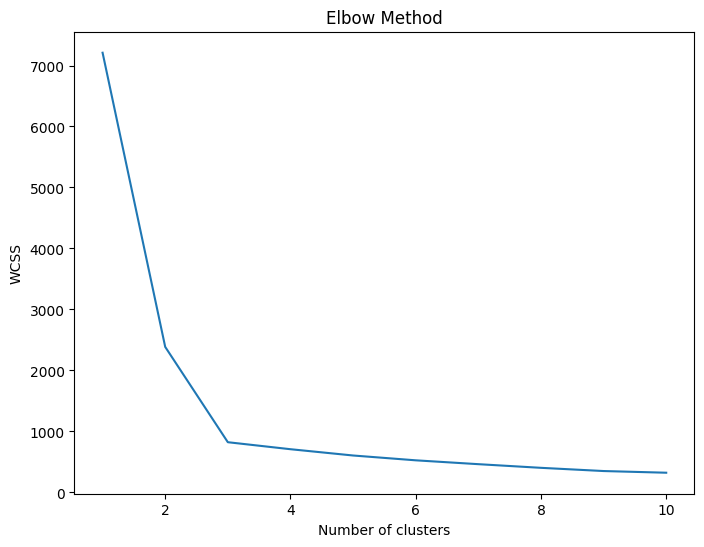

In [73]:
# Creation of an inertia graph and application of the elbow method

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(data)
    wcss.append(kmeans.inertia_)  
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()


### Inertia graph conclusion:

Indeed it seems that the optimal number of clusters is the one that we guessed initially 3 clusters. Here in the 3 cluster assumption it is clear that we have a "sharp" elbow that shows us the ideal number of clusters

# Ex 1.2

In [74]:
import numpy as np
from sklearn.cluster import KMeans

def davies_bouldin_index(X, labels):
    """
    Calculates the DBI

    Input:
        X: The data matrix.
        labels: The cluster labels for each data point.

    output:
        The DBI
    """

    n_clusters = len(np.unique(labels))
    cluster_centers = np.array([X[labels == i].mean(axis=0) for i in range(n_clusters)])

    # Calculate the average distance between each data point and its cluster centroid
    S = np.array([np.mean(np.linalg.norm(X[labels == i] - c, axis=1)) for i, c in enumerate(cluster_centers)])

    # Calculate the pairwise distances between cluster centers
    M = np.zeros((n_clusters, n_clusters))
    for i in range(n_clusters):
        for j in range(n_clusters):
            if i != j:
                M[i, j] = np.linalg.norm(cluster_centers[i] - cluster_centers[j])

    # Calculate the DBI
    DBI = np.mean([np.max([(S[i] + S[j]) / M[i, j] for j in range(n_clusters) if i != j]) for i in range(n_clusters)])

    return DBI


X = X_scaled 

# K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=0).fit(X)
labels_3 = kmeans.labels_
db_index_3 = davies_bouldin_index(X, labels_3)

# K-Means with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=0).fit(X)
labels_5 = kmeans.labels_
db_index_5 = davies_bouldin_index(X, labels_5)

print("Davies-Bouldin Index for 3 clusters:", db_index_3)
print("Davies-Bouldin Index for 5 clusters:", db_index_5)

Davies-Bouldin Index for 3 clusters: 0.34721323519352837
Davies-Bouldin Index for 5 clusters: 0.5501771701795419


Due to Davies bouldin index having a lower value for 3 clusters than for 5 we can conclude that 3 is the optimal number 
of them.One statistical way to compare them is silhouette score:


In [75]:
from sklearn.metrics import silhouette_score
kmeans_3 = KMeans(n_clusters=3, random_state=0).fit(X)
labels_3 = kmeans_3.labels_
silhouette_3 = silhouette_score(X, labels_3)

kmeans_5 = KMeans(n_clusters=5, random_state=0).fit(X)
labels_5 = kmeans_5.labels_
silhouette_5 = silhouette_score(X, labels_5)

print("Silhouette Score for 3 clusters:", silhouette_3)
print("Silhouette Score for 5 clusters:", silhouette_5)

Silhouette Score for 3 clusters: 0.7187126911402217
Silhouette Score for 5 clusters: 0.582409017862548


 The silhouette ranges from -1 to 1, where a high value indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters.This confirms that 3 clusters is the optimal number of clusters between the two options as its higher than the 5 cluster option.

# Ex.1.4

In [76]:
import numpy as np

def calinski_harabasz_index(X, laabels):
    """
    Calculates the Calinski-Harabasz Index.

    Args:
        X: The data matrix.
        labels: The cluster labels for each data point.

    Returns:
        The Calinski-Harabasz Index.
    """

    n_samples, n_features = X.shape
    n_clusters = len(np.unique(labels))

    
    cluster_centers = np.array([X[labels == i].mean(axis=0) for i in range(n_clusters)])

    # Calculate the within-cluster dispersion matrix (W)
    W = np.zeros((n_features, n_features))
    for i in range(n_clusters):
        Xi = X[labels == i]
        W += np.dot((Xi - cluster_centers[i]).T, (Xi - cluster_centers[i]))

    # Calculate the between-cluster dispersion matrix (B)
    B = np.zeros((n_features, n_features))
    for i in range(n_clusters):
        n_i = len(X[labels == i])
        B += n_i * np.outer(cluster_centers[i] - X.mean(axis=0), cluster_centers[i] - X.mean(axis=0))

    # Calculate the trace of the matrices
    trace_W = np.trace(W)
    trace_B = np.trace(B)

    # Calculate the Calinski-Harabasz Index
    CH_index = (trace_B / (n_clusters - 1)) / (trace_W / (n_samples - n_clusters))

    return CH_index
    
kmeans = KMeans(n_clusters=3, random_state=0).fit(X)
labels = kmeans.labels_

ch_index = calinski_harabasz_index(X, labels)
print("Calinski-Harabasz Index:", ch_index)



Calinski-Harabasz Index: 4376.166561690476


### Conclusion regarding the calculated Calinski-Harabasz Index:

The high value that we ended up with indicates that the clusters are well separated 

# Ex.2.1

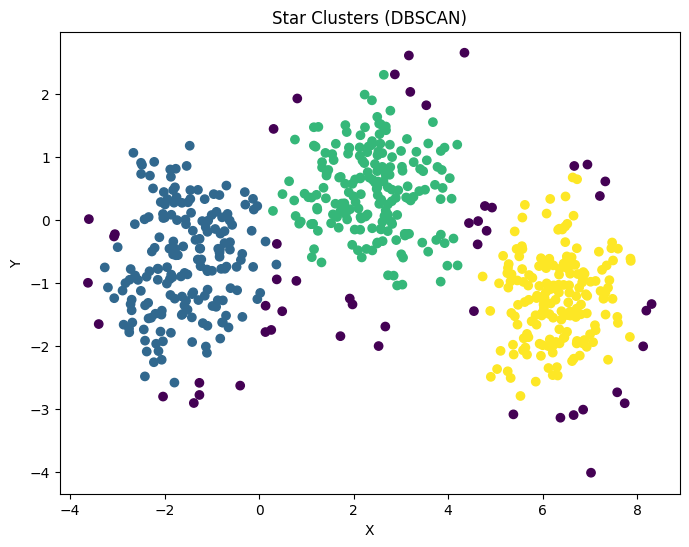

Number of clusters: 3
Number of noise points: 50


In [77]:
# DBSCAN clustering
dbscan = DBSCAN(eps=0.5149, min_samples=8)  # Adjust eps and min_samples as needed
labels = dbscan.fit_predict(data)


plt.figure(figsize=(8, 6))
plt.scatter(data['RA'], data['Dec'], c=labels)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Star Clusters (DBSCAN)')
plt.show()


unique_labels = set(labels)
n_clusters = len(unique_labels) - (1 if -1 in labels else 0)  # Exclude noise points

# Count the number of noise points
n_noise = list(labels).count(-1)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)


# Debate whether to use the KMeans or DBSCAN:

From data visualisation results we notice that the clusters appear to be close to spherical and that they are of similar size.

They are also well separated, indicated by the results yielded from the Calinski-Harabasz Index. 

This is why we believe that the use of KMeans will be most optimal. It is the go-to method for these kind of situation since 
from visualisation alone we can specify the number of clusters beforehand. It also provides the advantage of low computational cost.

On the other hand the DBSCAN method is way too arbitrary to use when it comes to setting its hyperparameters. With the best combination
of the eps and min_samples ,so far, we got 50 outliers designated as noise, that's nearly 10% of the whole data set and from post visualisation 
we can see that some of them can be considered parts of a cluster. We even attempted to normalise the data before proccessing them but this
proccess only added more reasons to reject the DBSCAN method as we ended up having more of 15% of the database designated as noise for the
aggreed upon number of clusters.